In [1]:
import torch
# torch.autograd.set_detect_anomaly(True)
from torch.utils.data import DataLoader,WeightedRandomSampler
from torch.optim.lr_scheduler import PolynomialLR
import torch.nn.functional as F
from torchvision.transforms import v2

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

from tqdm.notebook import tqdm
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random
###IE###
%load_ext autoreload
%autoreload 2
from utils.helpers import (
    plot_some_images ,read_images ,
    pre_hard_skeletonize , pre_soft_skeletonize,
    compute_confution_matrix,draw_mask,TP_TN_FP_FN,)
from utils.preprocessing import (
    WhiteTopHat , CLAHE , normalize_xca,
    BrightnessMultiplicativeNNUNet2D,
    ContrastAugmentationNNUNet2D)
from utils.dataset import  UnetDataset , ValidUnetDataset 
from models.nnunet import nnUnet
from utils.losses import UnetLoss
from utils.recorder import HistoryRecorder
from logger import save_full_report
from trainer import trainer
###SS###
from trainer import evaluation

In [2]:
args = {
    "base_path" : "../arcade/nnUnet_dataset/syntax",
    "in_c" : 1,
    "base_channel" :32,
    "image_shape" : (448,448),
    "class_count" : 3 ,
    "attention" : False,
    "k":40,
    "batch_size" : 20,
    "num_workers" : 5,
    "device" : "cuda" if torch.cuda.is_available() else "cpu",
    "lr" : 0.01,
    "momentum" : 0.99,
    "weight_decay" : 3e-5,
    "epcohs":200,
    "f_int_scale" : 2,
    "full_report_cycle" : 10,
    "max_channels":512,
    "input_channels":1,
    "loss_type":"tversky loss",
    "alpha":0.3,
    "beta":0.8,
    "t_gamma":2.00,
    "f_gamma":2.0,
    "f_loss_scale":1,
    "loss_coefs":{"CE":1.0,"Second":1.0},
    "output_base_path" : "./outputs",
    "name" : "15-14b-4layer",
    "deep_super_vision" : False,
    "f_alpha":None,
    "layer_count":4
}
# class_map = {
#     1: '1',2: '2', 3: '3',4: '4',
#     5: '5',6: '6',7: '7',8: '8',
#     9: '9',10: '9a',11: '10',12: '10a',
#     13: '11',14: '12',15: '12a',16: '13',
#     17: '14',18: '14a',19: '15',20: '16',
#     21: '16a',22: '16b',23: '16c',
#     24: '12b',25: '14b'
# }
class_map = {
    1:'15',
    2:'14b'
}
# losses_keys = ["total loss","FCE loss",args["loss_type"]]
losses_keys = ["total loss","CE loss",args["loss_type"]]
out_counts = args["layer_count"] if args["deep_super_vision"] else 1
loss_weights = [1/(2**i) for i in range(out_counts)]
loss_weights



[1.0]

In [3]:
b=0.999
train_class_counts = [
    1200,374,375,369,303,525,525,
    340,310,198,70,21,1,320,61,
    129,305,107,49,38,232,43,48,31,63,127
]
# f_alpha = (1-b)/(1-np.power(b,train_class_counts))
total = np.sum(train_class_counts)
f_alpha = np.log(total/np.array(train_class_counts))
f_alpha = (f_alpha / f_alpha.mean()).tolist()
# args["f_alpha"] = [0.1,1.75,1.5]
args["f_alpha"]=None
f_alpha


[0.4192306623653949,
 0.7179025174767664,
 0.7172184312490237,
 0.7213506198648413,
 0.7718364322603585,
 0.6310175618202434,
 0.6310175618202434,
 0.7423200457906856,
 0.7659851796135413,
 0.8808365687040562,
 1.1472158488751967,
 1.4556618102528003,
 2.235638440011511,
 0.7578514761453713,
 1.1824730889495298,
 0.9906024194367986,
 0.7701509647332515,
 1.0385057663997224,
 1.238592452721393,
 1.3037247322439667,
 0.8402380298539683,
 1.2720560555504503,
 1.2438749107979519,
 1.3558847771047964,
 1.1742081741391486,
 0.9946054718189865]

In [4]:
# args["t_alpha"] = [1,0.8]
args["t_alpha"] = None

In [5]:


train_transforms = A.Compose([
    A.Resize(*args["image_shape"]),
        A.Downscale(
        scale_range=[0.7, 1],
        interpolation_pair={"downscale": 0, "upscale": 0},
        p=0.5
    ),
    A.GaussNoise(
        std_range=[0.0, 0.1],
        mean_range=[0, 0],
        per_channel=True,
        noise_scale_factor=1,
        p=0.5
    ),
    A.GaussianBlur(
        sigma_limit=[1.0,1.5],
        blur_limit = (3,7),
        p=0.5
    ),

    A.OneOf([
        A.ElasticTransform(
            alpha=120, 
            sigma=120 * 0.05, 
            p=1.0
        ),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
        A.OpticalDistortion(distort_limit=0.2, p=1.0),
    ], p=0.5),
    A.Compose([
        A.InvertImg(p=1.0),
        A.RandomGamma(gamma_limit=(70, 150), p=1.0),
        A.InvertImg(p=1.0),
    ], p=0.5),
    BrightnessMultiplicativeNNUNet2D(multiplier_range=(0.70, 1.3), p=0.5),
    ContrastAugmentationNNUNet2D(contrast_range=(0.65, 1.5), p=0.5),
    A.RandomGamma(
        gamma_limit=(90, 120), 
        p=0.5
    ),
    A.Affine(
        scale=(0.7, 1.4),  
        translate_percent=(0, 0),
        rotate=0,               
        shear=0,                 
        fit_output=False, 
        p=0.5
    ),
    A.Rotate(limit=30, p=0.5, fill_mask = 0),
    A.Rotate(limit=-30, p=0.5, fill_mask = 0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    # A.Lambda(image=normalize_xca)
    A.Normalize(
        mean=(0.485,), 
        std=(0.229,),
        max_pixel_value=255.0, 
        p=1.0),
    ]
)
test_transforms = A.Compose([
    A.Resize(*args["image_shape"]),
    # A.Lambda(image=normalize_xca),
    A.Normalize(
        mean=(0.485,), 
        std=(0.229,),
        max_pixel_value=255.0, 
        p=1.0),
    ToTensorV2()
    ]  
)

train_preprocess = None


/home/parsa/Masters/Coronary Artry/Datasets/Arcade/codes/utils/preprocessing.py:47: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)
/home/parsa/Masters/Coronary Artry/Datasets/Arcade/codes/utils/preprocessing.py:60: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)


In [6]:
train_images = read_images(base_path = args["base_path"],preprocessor = train_preprocess,part = "train",chosen_labels=[19,25])
valid_images = read_images(base_path = args["base_path"],preprocessor = train_preprocess,part = "val",chosen_labels=[19,25])


NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/1000 [00:00<?, ?it/s]

NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/200 [00:00<?, ?it/s]

In [7]:
empty_images = []
just_15 = []
just_14b = []
both = []
for img , label in train_images:
    u = np.unique(label)
    if(len(u)==1):
        empty_images.append([img,label])
    elif(len(u)==2):
        if(2 in u):
            just_14b.append([img,label])
        else:
            just_15.append([img,label])
    else:
        both.append([img,label])
def change_ds(lists , sizes,class_weights):
    sampler_weights = []
    for i,size in enumerate(sizes):
        list = lists[i]
        if(len(list)>size): # sample from it
            lists[i]=random.sample(list,k=size)
        else:
            old_list = list
            sample_size = size - len(list)
            if(sample_size>len(list)): #  sample with repeat
                sampled_list = random.choices(list,k=sample_size)
            elif(sample_size==0): # size is the same as list
                sampled_list = []
            else:
                sampled_list = random.sample(list,k=sample_size)
                
            lists[i] = sampled_list + old_list
        sampler_weights += [class_weights[i]]*size
    return lists,sampler_weights
print(len(empty_images),len(just_15),len(just_14b),len(both))
lists , sampler_weights = change_ds(
    lists=[empty_images,just_15,just_14b,both],
    sizes=[844,31,118,7],
    class_weights=[0.001,1/31,1/127,1/31]
)
empty_images , just_15 , just_14b , both = lists
print(len(empty_images),len(just_15),len(just_14b),len(both))
train_images = empty_images + just_15 + just_14b + both

844 31 118 7
844 31 118 7


In [8]:

train_ds = UnetDataset(transform = train_transforms,data = train_images,base_size=args["image_shape"][0],out_counts=out_counts)
valid_ds = ValidUnetDataset(transform = test_transforms,data = valid_images)
sampler = WeightedRandomSampler(
    weights=sampler_weights, 
    num_samples=len(sampler_weights),
    replacement=True)

train_loader = DataLoader(
    train_ds,
    batch_size = args["batch_size"] ,
    num_workers = args["num_workers"] ,
    pin_memory=True,
    shuffle=False,
    sampler=sampler
)
valid_loader = DataLoader(
    valid_ds,
    batch_size = 10 ,
    num_workers = args["num_workers"] ,
    pin_memory=True,
    shuffle=False,
)


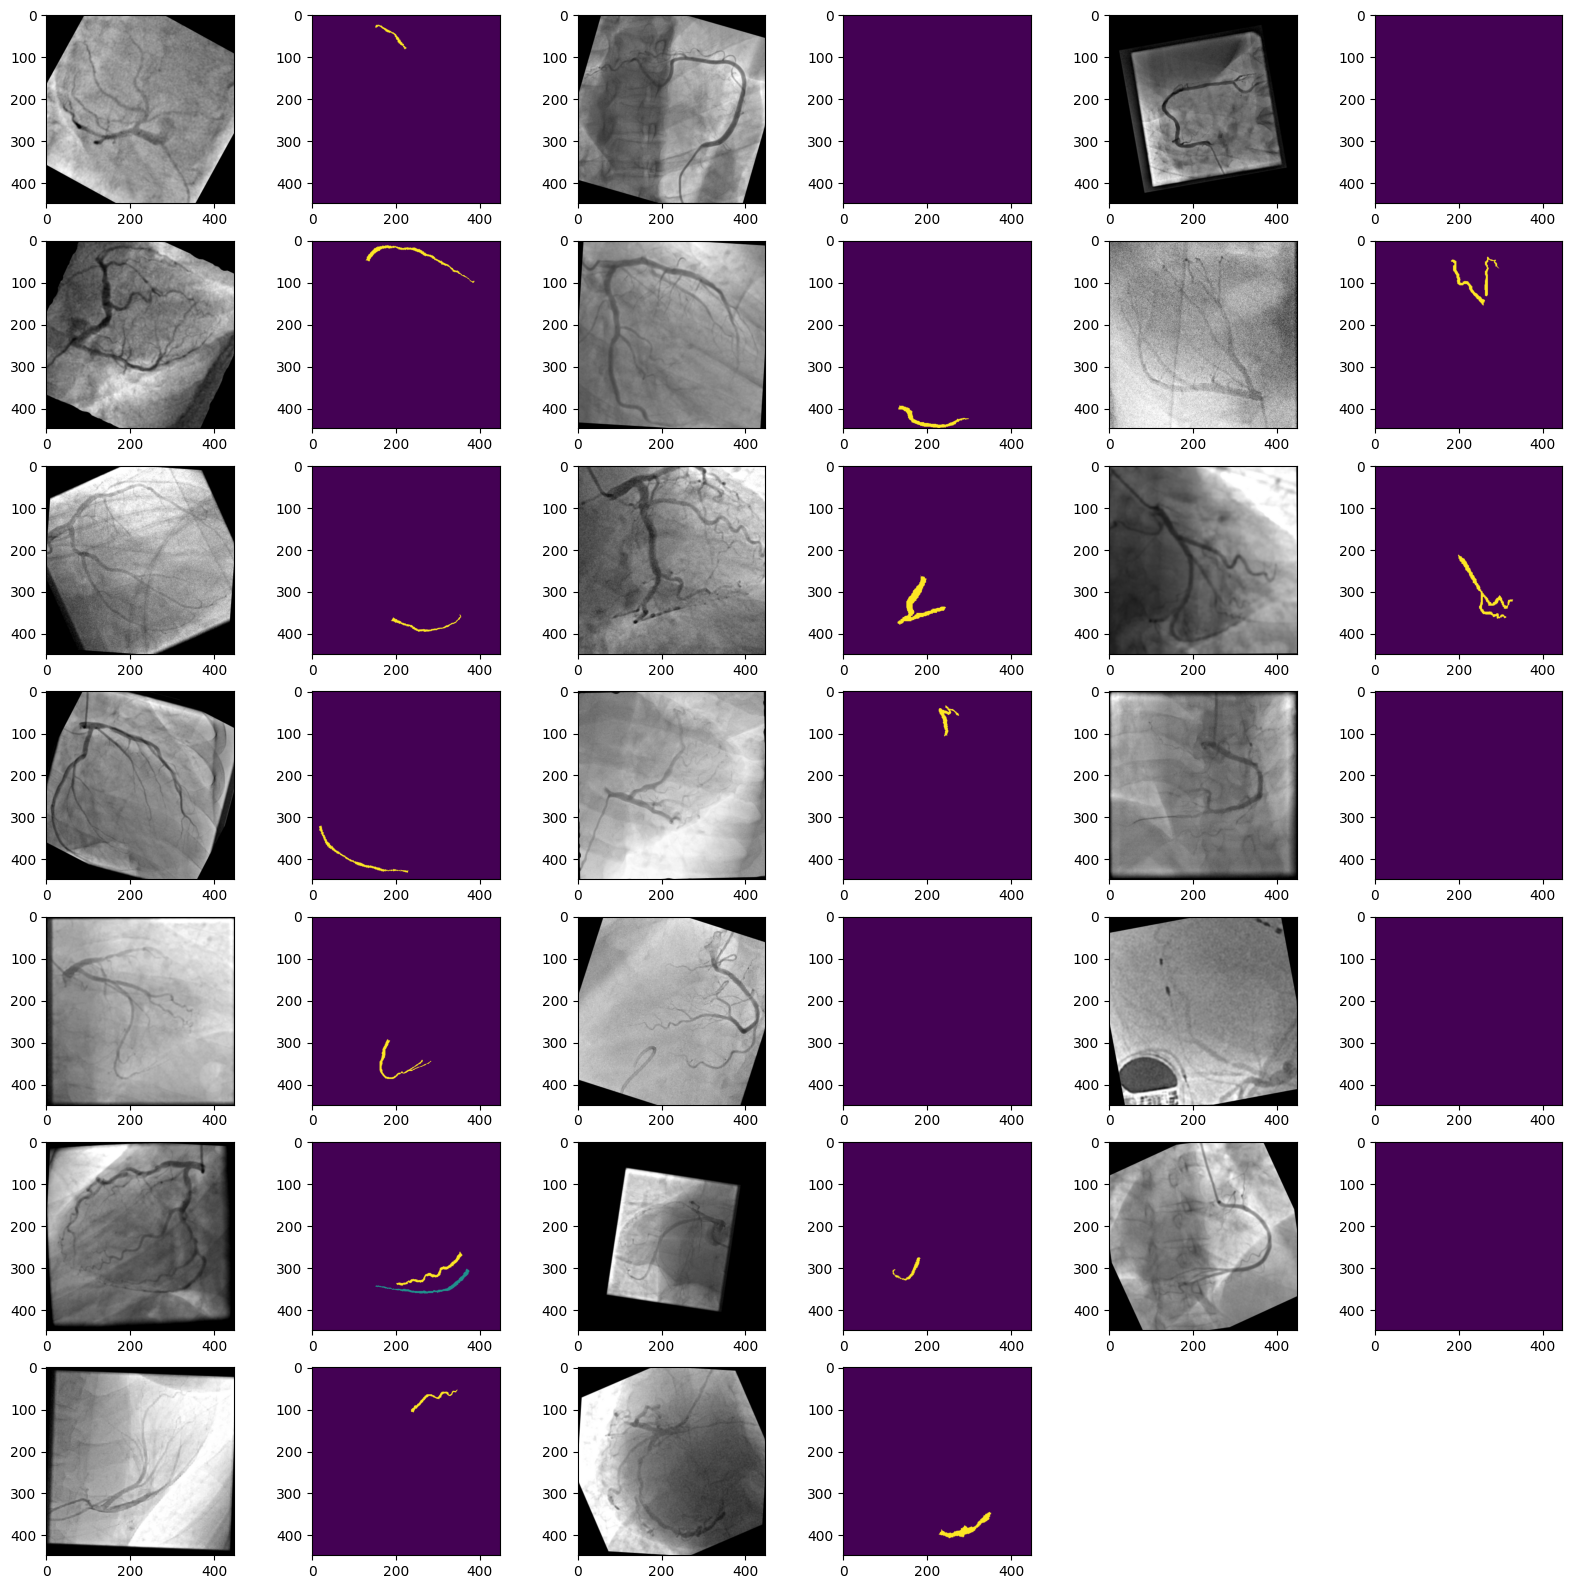

In [9]:
imgs , labels = next(iter(train_loader))
labels=labels[0]
plt.figure(figsize=(20,20))
i=1
for j,img in enumerate(imgs):

    plt.subplot(7,6,i)
    plt.imshow(img[0].numpy(),cmap="gray")
    plt.subplot(7,6,i+1)
    plt.imshow(labels[j].numpy()*100)
    i+=2

In [10]:
class Unet(torch.nn.Module):
    def __init__(self, args):
        super(Unet,self).__init__()
        self.model = smp.Unet(
            encoder_name="resnet18",     # Reliable backbone
            encoder_weights="imagenet",  # Start with pre-trained edges
            in_channels=1,               # Grayscale adaptation
            classes=3,                   # Bg, 14b, 15
            encoder_depth=3,

            decoder_channels=(64, 32, 16) 
        )
        # for param in self.model.encoder.parameters():
        #     param.requires_grad = False
        # for param in self.model.encoder.features[-1].parameters():
        #     param.requires_grad = True
    def forward(self,x):
        return [self.model(x)]
    

In [11]:

# model = nnUnet(args).to(args["device"])

model = Unet(args).to(args["device"])


loss_fn = UnetLoss(args)
# optimizer = torch.optim.Adam(model.parameters(), lr=args["lr"])
# optimizer = torch.optim.SGD(
#     model.parameters(),
#     momentum=args["momentum"],
#     lr=args["lr"],
#     nesterov=True,
#     weight_decay=args["weight_decay"]
# )
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
lr_sch = PolynomialLR(optimizer=optimizer,total_iters=args["epcohs"],power=0.9)
recorder = HistoryRecorder(losses_keys=losses_keys,class_maps =class_map,class_count=args["class_count"]-1)


best_model = trainer(
    args=args,
    recorder = recorder,
    model = model,
    optimizer = optimizer,
    loss_fn = loss_fn,
    train_loader = train_loader,
    valid_loader = valid_loader,
    loss_weights=loss_weights,
    lr_sch = lr_sch
)




model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

loss is set to tversky


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

current lr : 0.0001
train ==> epcoh (0)
total loss : 1.4794949626922607 - CE loss : 0.49728188157081604 - tversky loss : 0.9822130799293518

train avg metrics for epoch 0 :
avg dice : 0.00784517009742558 - avg precision : 0.004110071691684425 - avg recall : 0.08698220551013947
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (0)
total loss : 1.352741277217865 - CE loss : 0.3582413956522942 - tversky loss : 0.9944998741149902

valid avg metrics for epoch 0 :
avg dice : 0.0036527815682347864 - avg precision : 0.0022554938768735155 - avg recall : 0.02329719066619873
------------------------------------------------------------
New Best! : dice = 0.003652781480923295


...

current lr : 9.322e-05
train ==> epcoh (15)
total loss : 0.7322012114524842 - CE loss : 0.040776039510965346 - tversky loss : 0.691425170302391

train avg metrics for epoch 15 :
avg dice : 0.19278345257043839 - avg precision : 0.15021326579153538 - avg recall : 0.2831108942627907
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (15)
total loss : 0.9422345757484436 - CE loss : 0.02002184619195759 - tversky loss : 0.9222127288579941

valid avg metrics for epoch 15 :
avg dice : 0.0562996631488204 - avg precision : 0.04177143704146147 - avg recall : 0.22506891936063766
------------------------------------------------------------
New Best! : dice = 0.056299664080142975


  0%|          | 0/50 [00:00<?, ?it/s]

current lr : 9.277e-05
train ==> epcoh (16)
total loss : 0.6999123549461365 - CE loss : 0.038410657905042174 - tversky loss : 0.6615016961097717

train avg metrics for epoch 16 :
avg dice : 0.21367665380239487 - avg precision : 0.1709300447255373 - avg recall : 0.2986753508448601
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (16)
total loss : 0.938298836350441 - CE loss : 0.02894436540082097 - tversky loss : 0.9093544632196426

valid avg metrics for epoch 16 :
avg dice : 0.05202079564332962 - avg precision : 0.03087603347375989 - avg recall : 0.2812017351388931
------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
with torch.no_grad():
    evaluation(
        recorder=recorder,
        model=best_model,
        loss_fn=loss_fn,
        valid_loader=valid_loader,
        class_count=args["class_count"],
        class_wise_report=True,
        epoch=0,
        device=args["device"]
    )

valid ==> epcoh (0)
total loss : 0.9101513445377349 - CE loss : 0.09087895135162398 - tversky loss : 0.819272381067276

valid avg metrics for epoch 0 :
avg dice : 0.1948961392045021 - avg precision : 0.16087818518280983 - avg recall : 0.2913450300693512
15 => dice : 0.13114245235919952 p : 0.0839785560965538 , r : 0.29915133118629456
14b => dice : 0.2586498260498047 p : 0.23777781426906586 , r : 0.28353872895240784
------------------------------------------------------------


Save Model
Saving Memory
Saving All Plots


  0%|          | 0/20 [00:00<?, ?it/s]

Saving Examples


  0%|          | 0/18 [00:00<?, ?it/s]

Saving Verbal Results
Copying Notebook To Results
builfding kaggle project


100%|██████████| 11/11 [00:00<00:00, 3563.28it/s]


processing ./utils/dataset.py
processing ./utils/helpers.py
processing ./logger.py
processing ./utils/preprocessing.py
processing ./utils/recorder.py
processing ./models/costume_nnunet_blocks.py
processing ./models/nnunet.py
processing ./models/swin_encoder.py
processing ./models/swin_blocks.py
processing ./utils/losses.py
processing ./trainer.py


100%|██████████| 1/1 [00:00<00:00,  4.35it/s]

processing ./temp_script.py


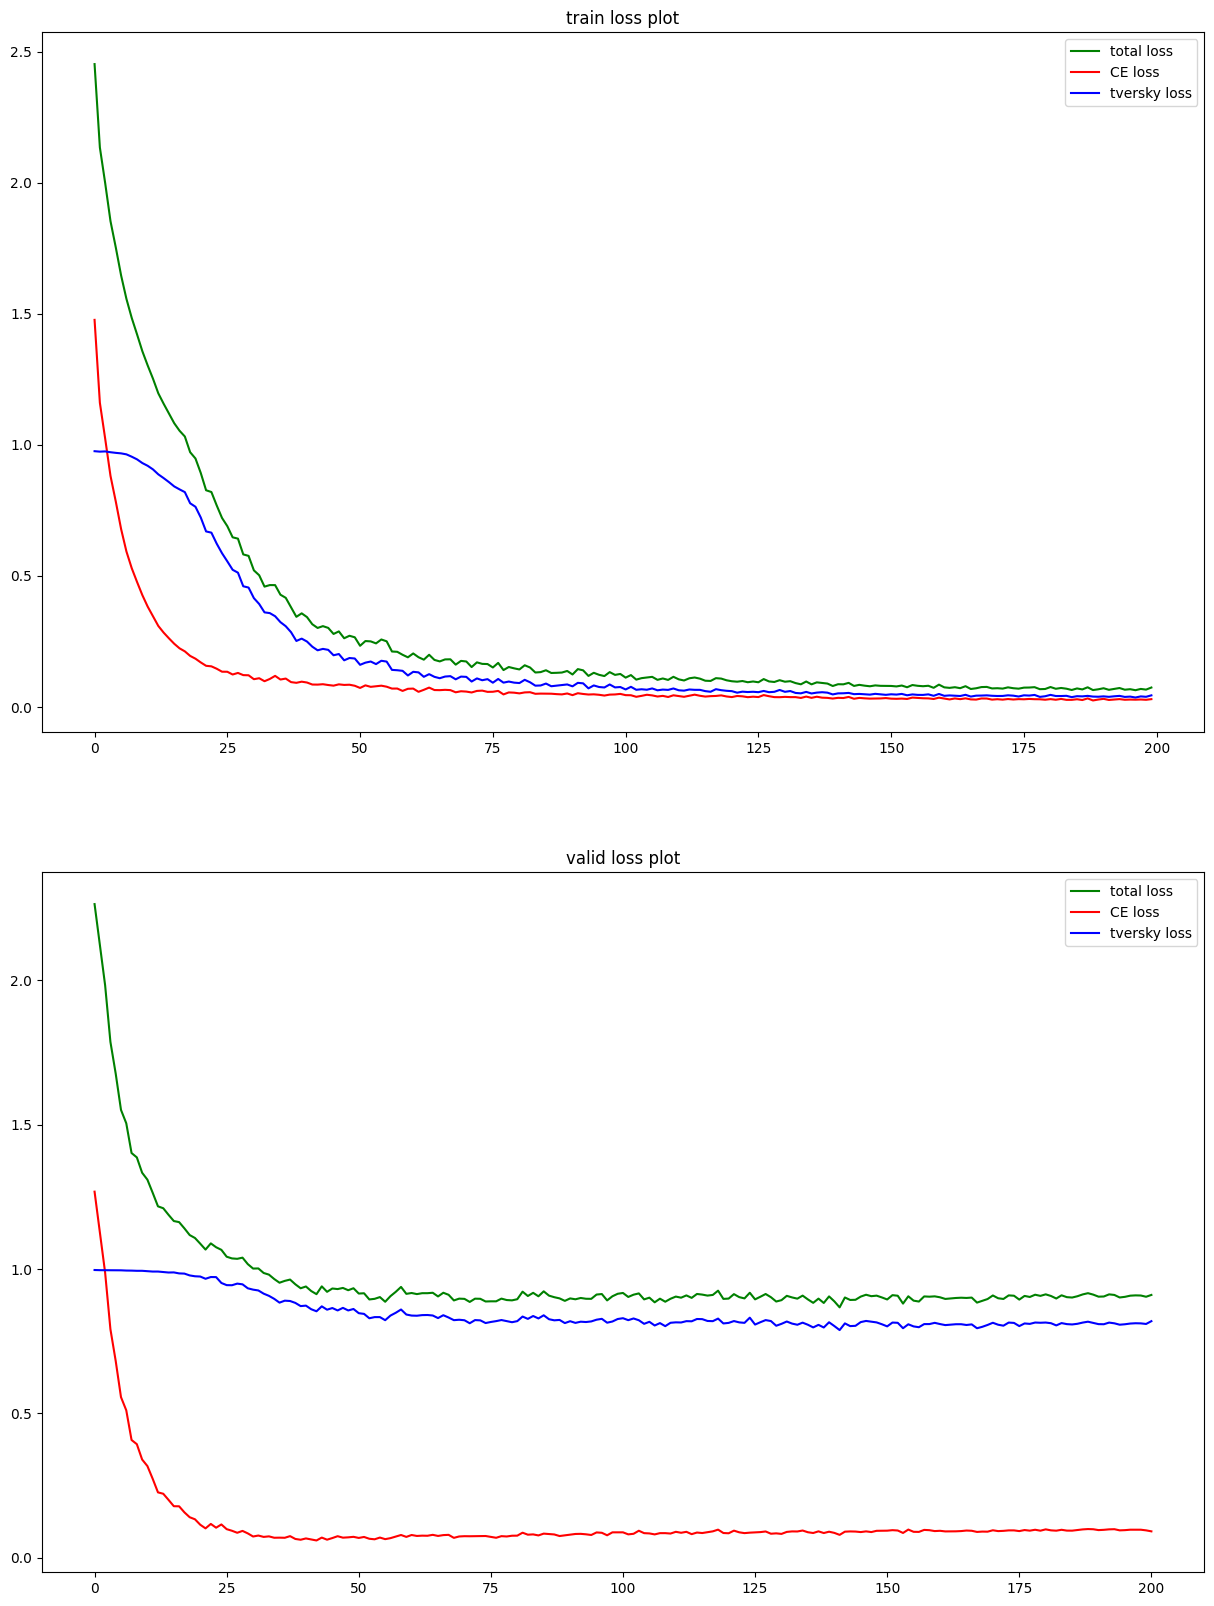

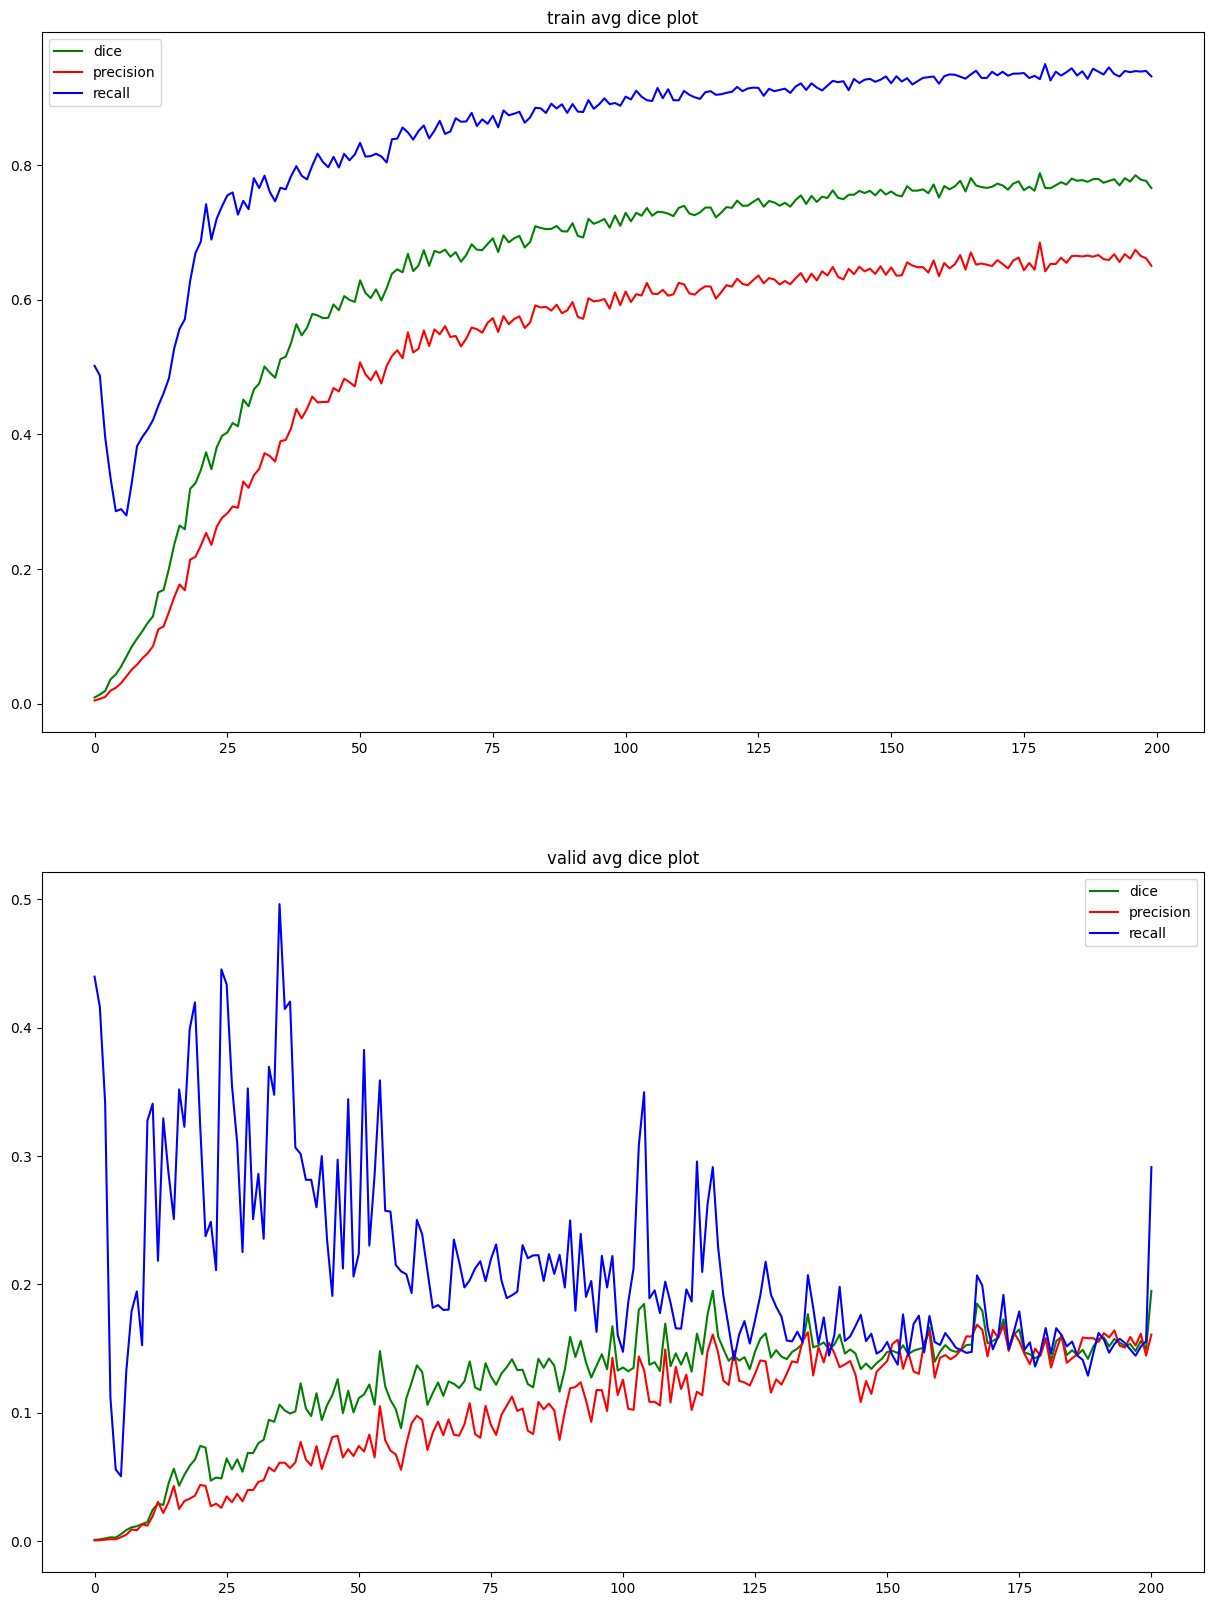

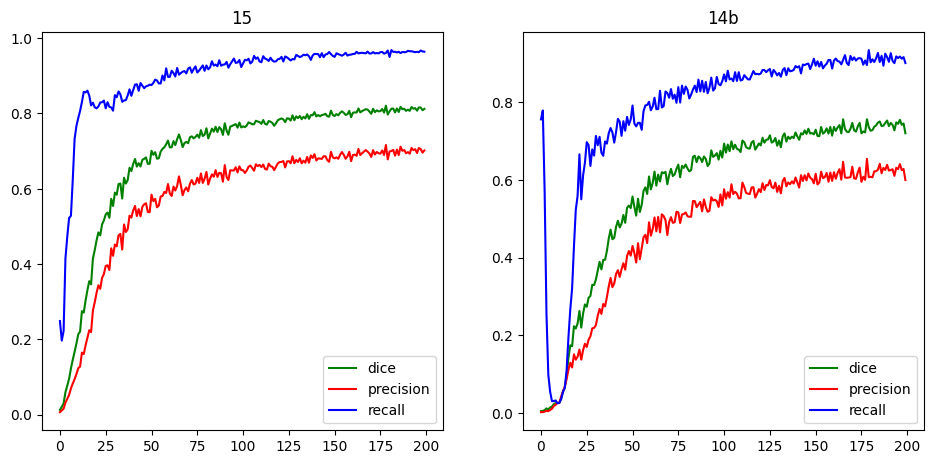

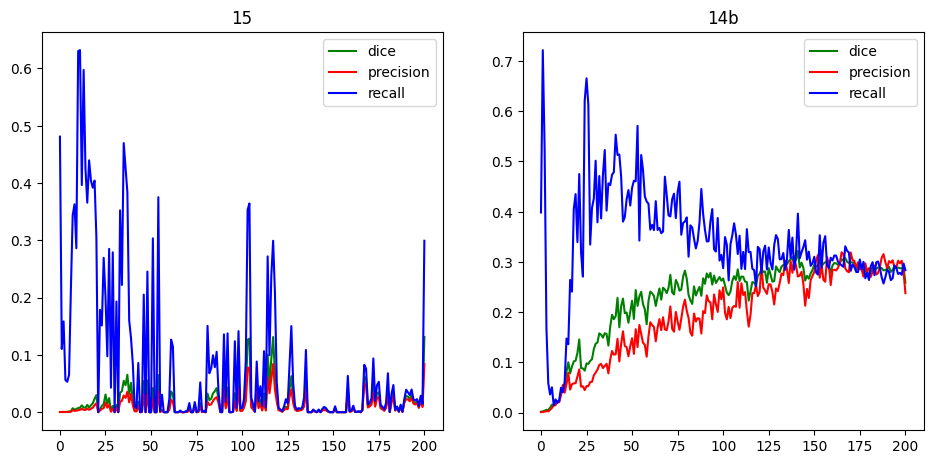

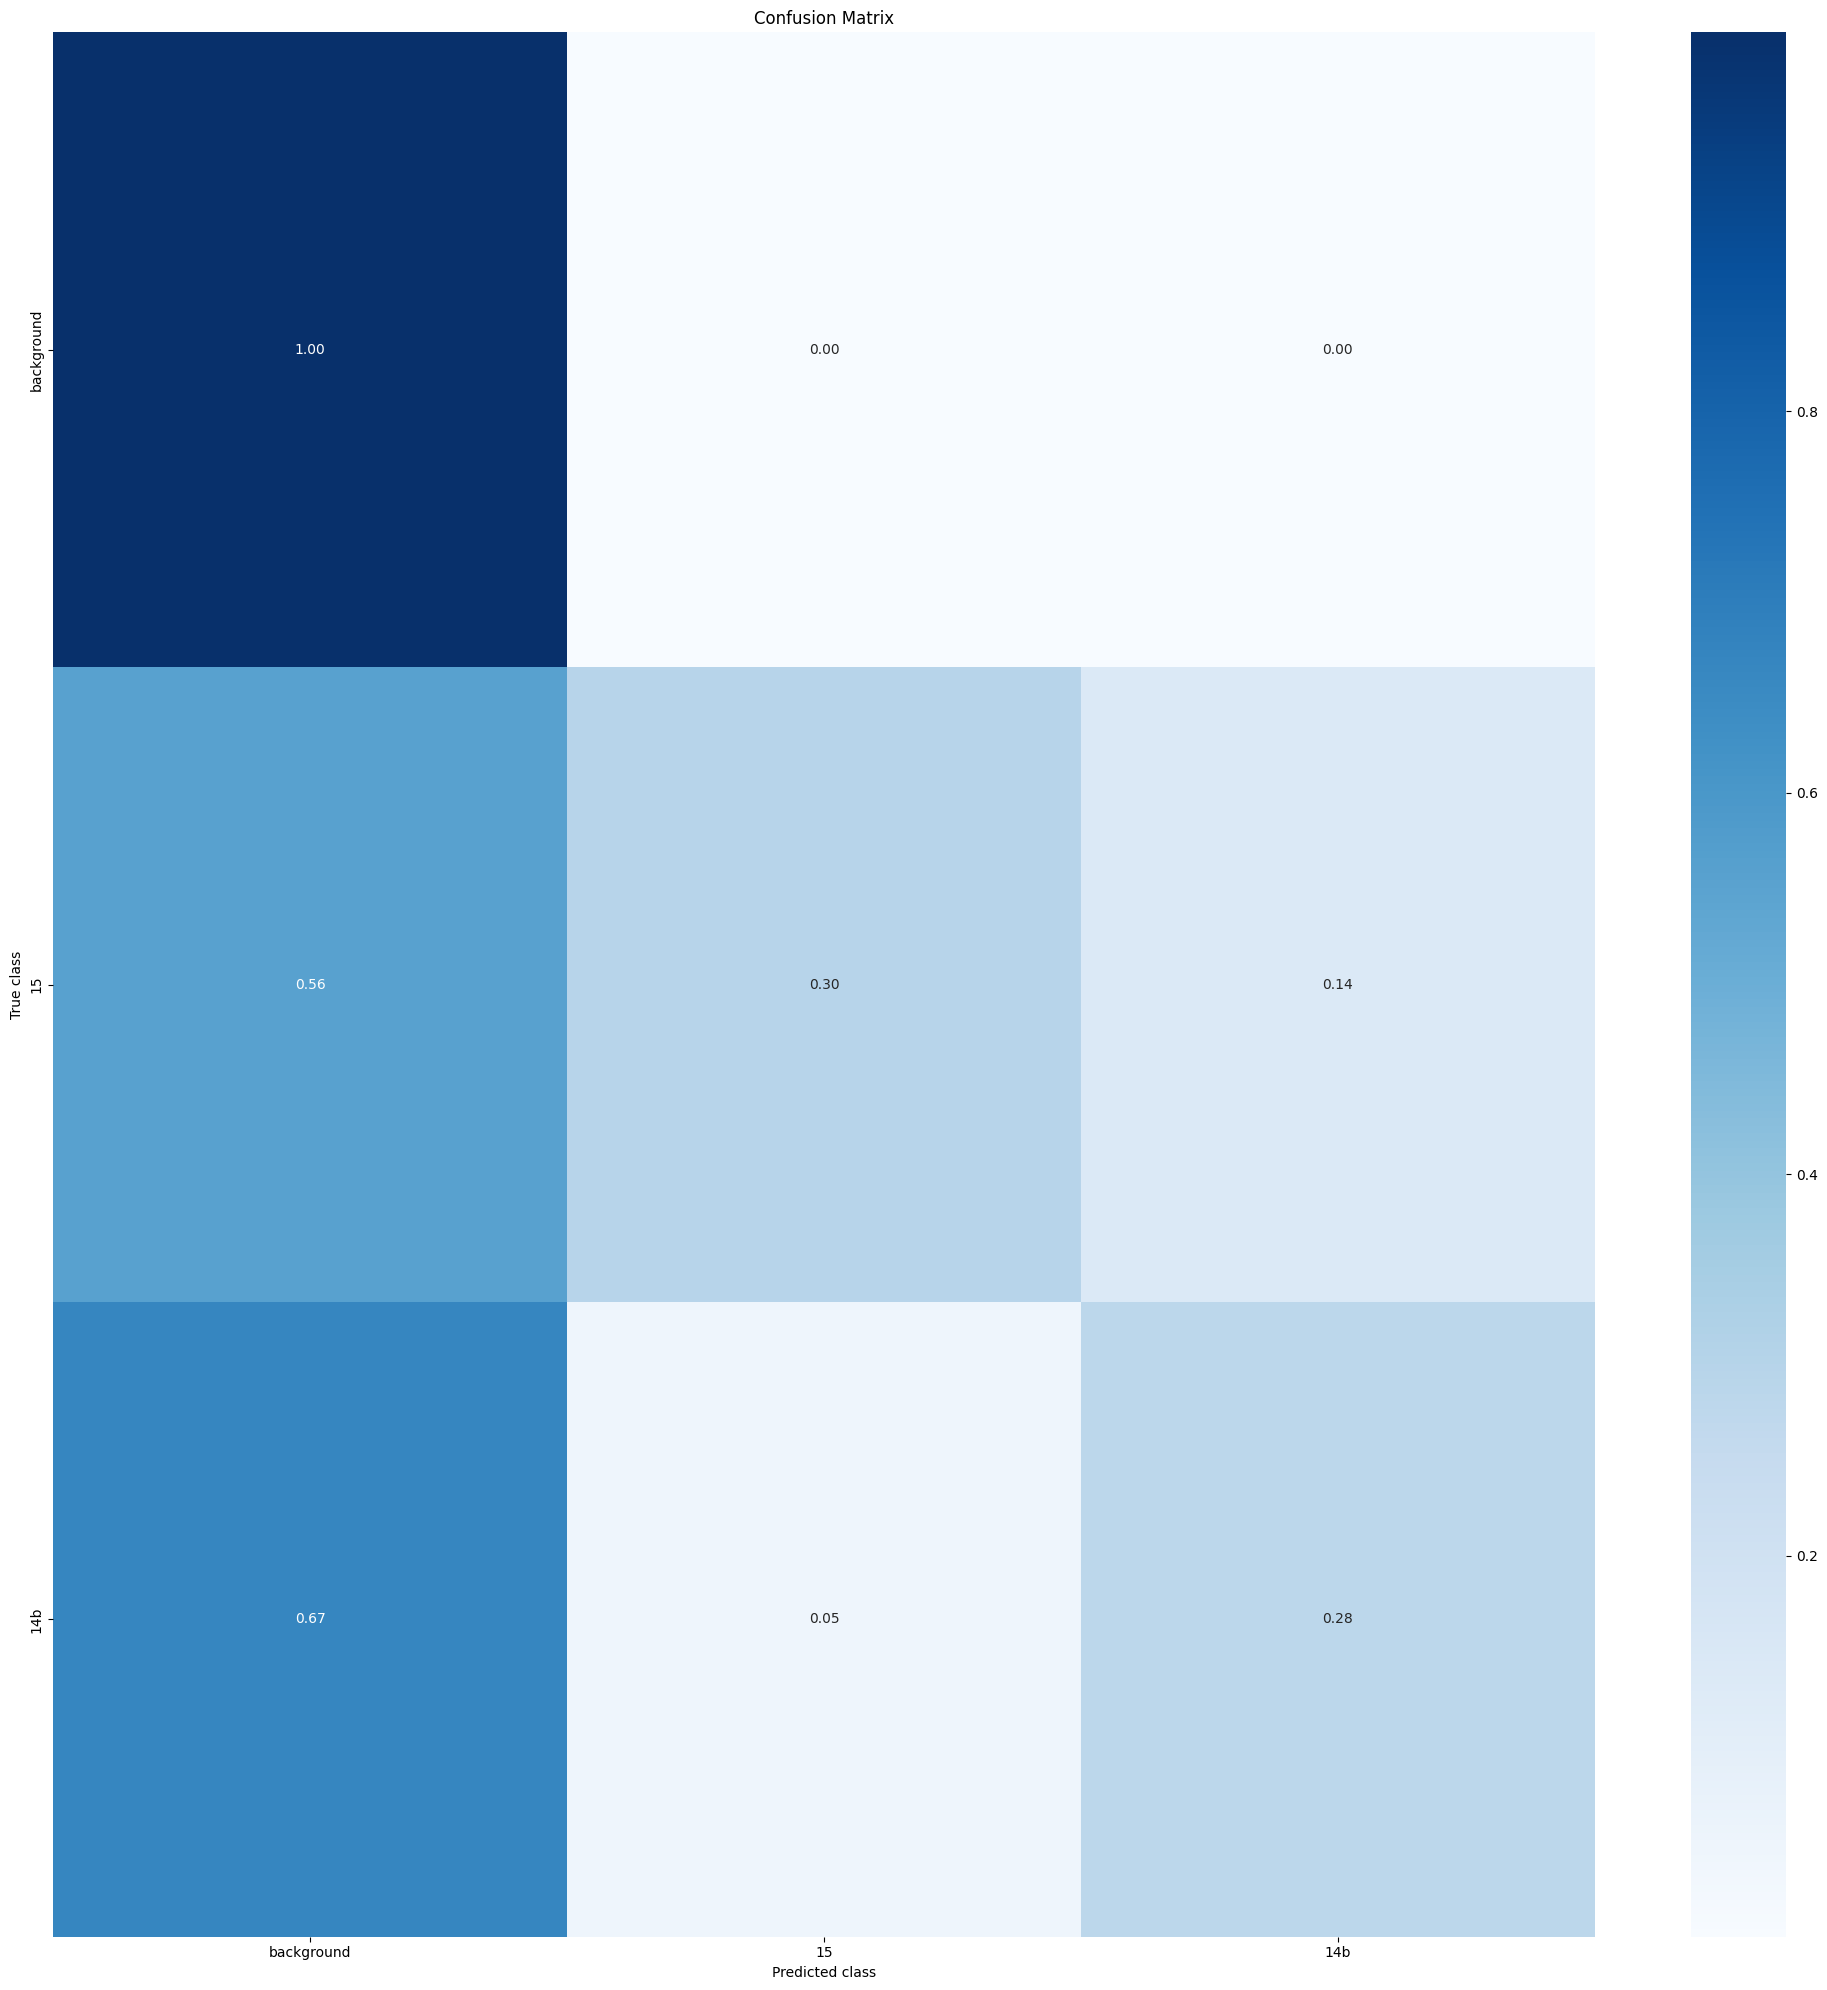

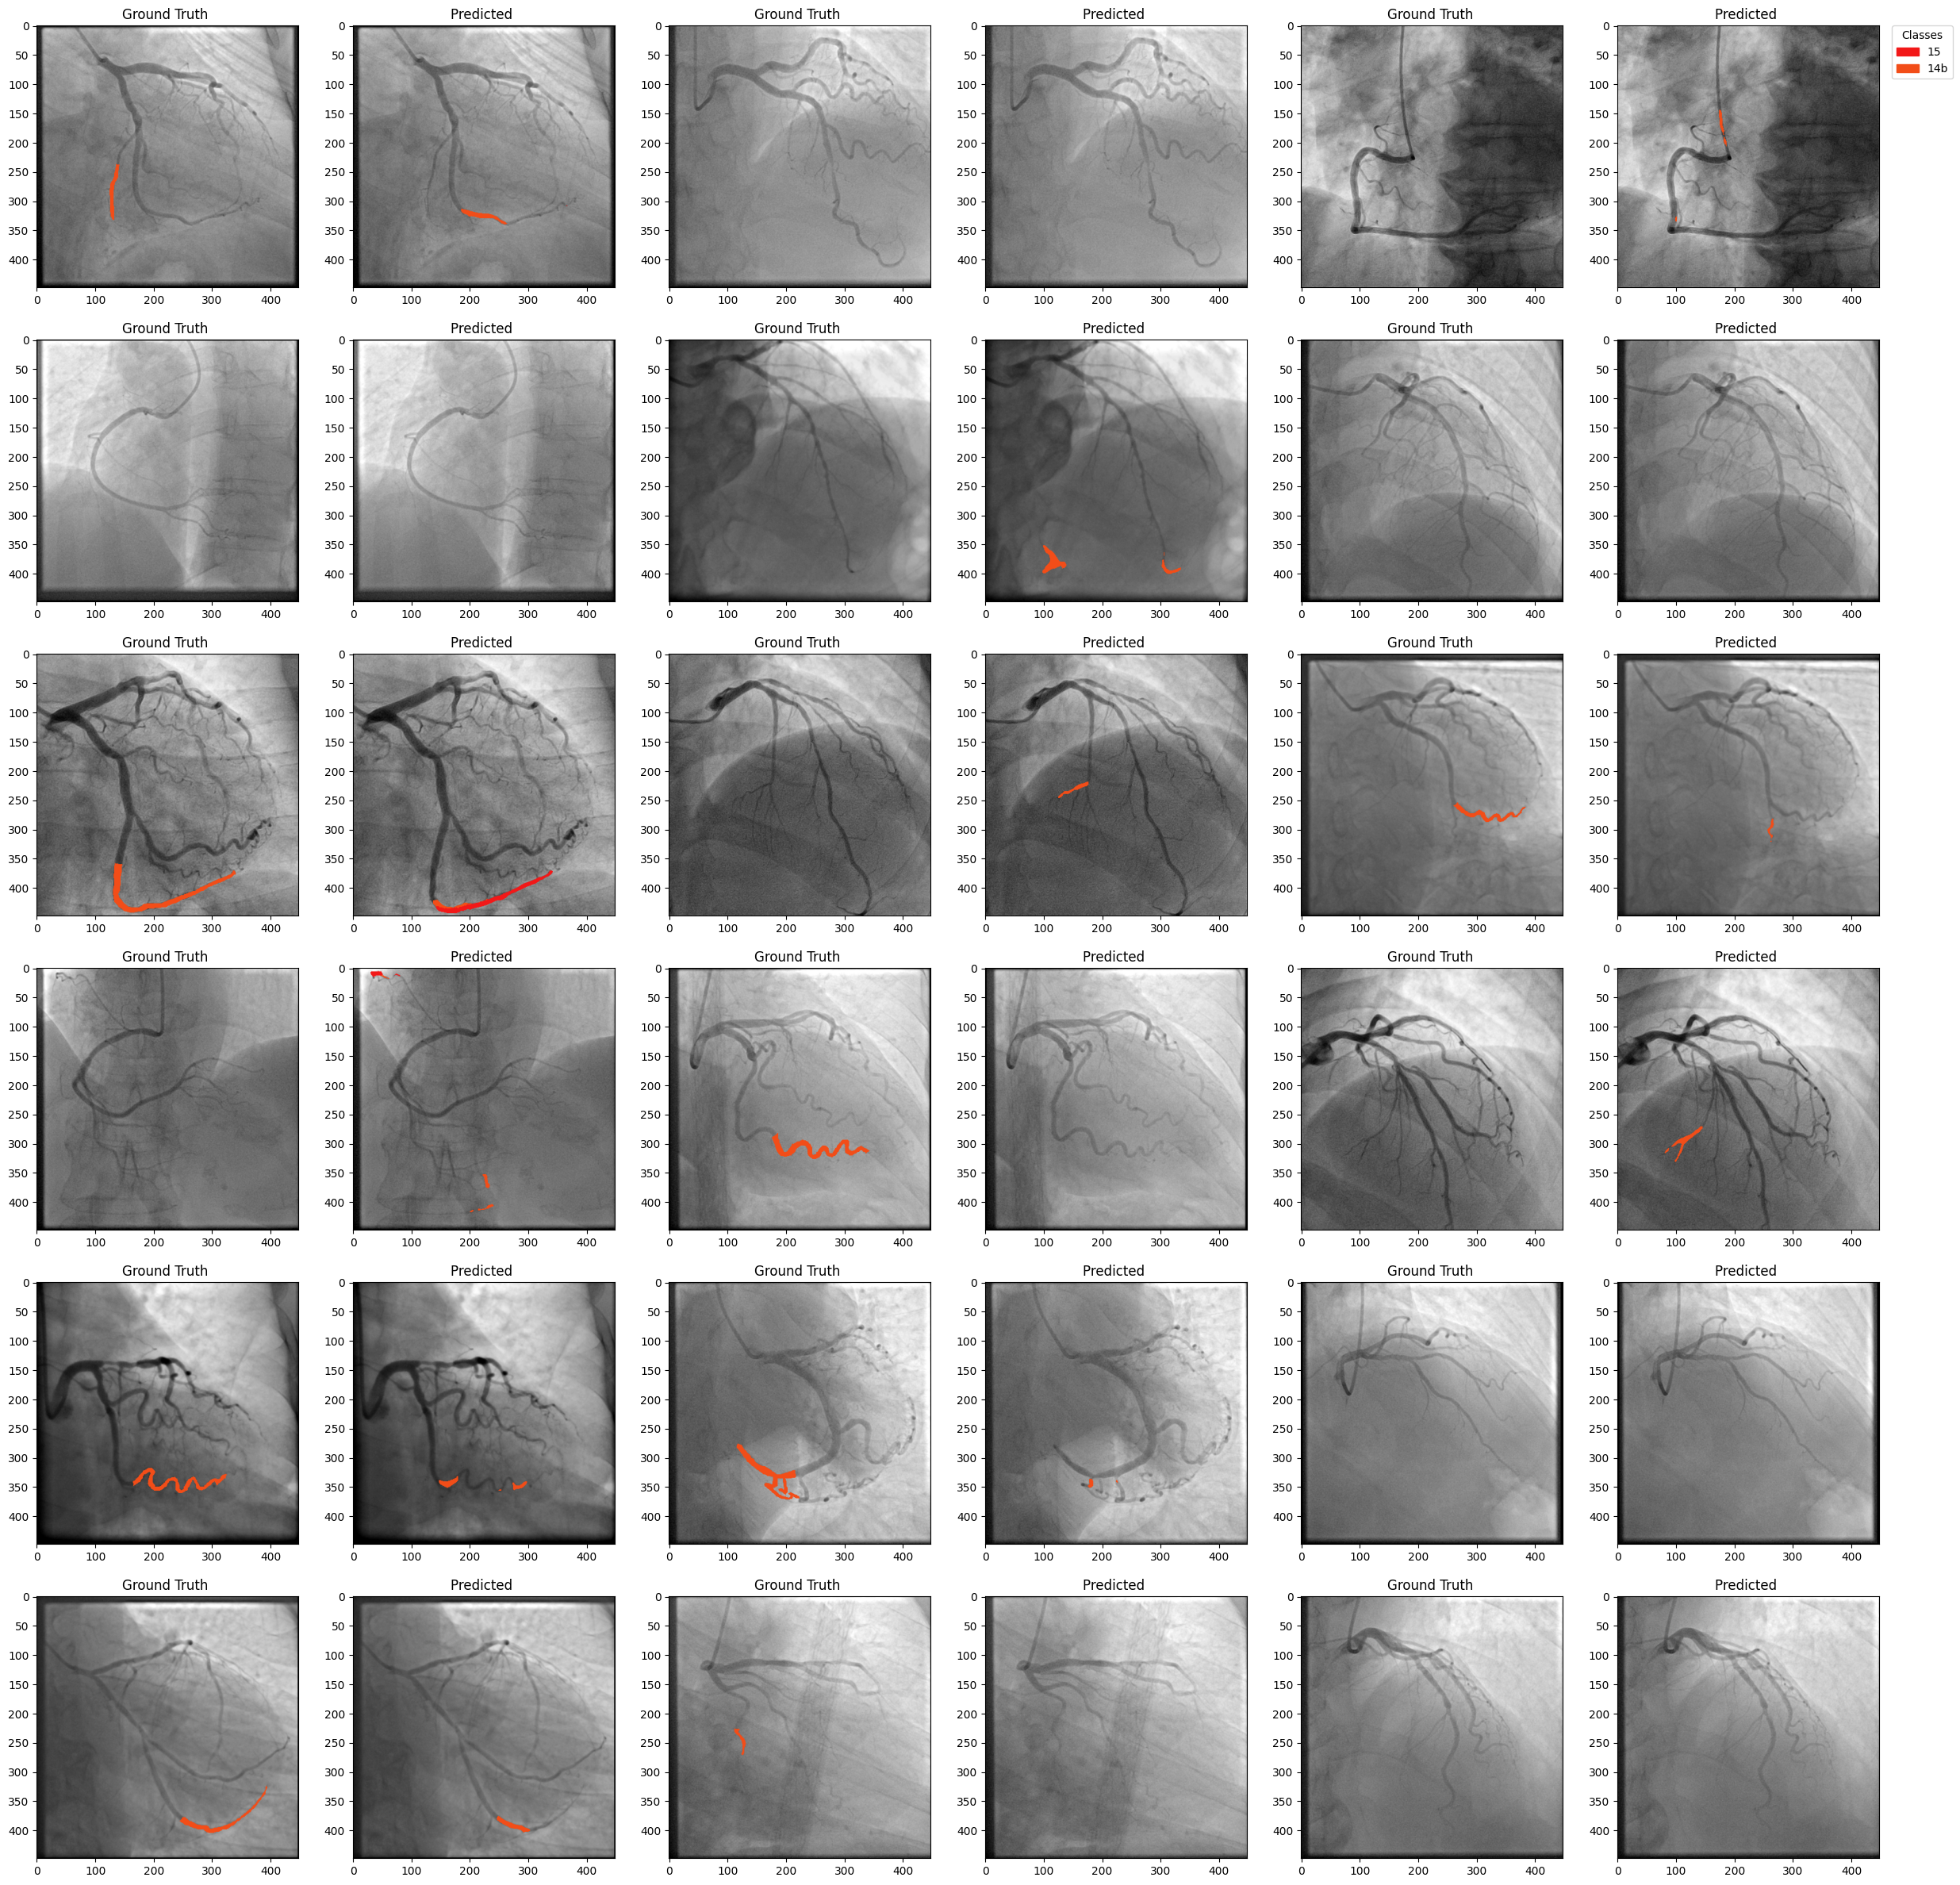

In [ ]:


save_full_report(
    recorder= recorder , 
    output_base_path=args["output_base_path"],
    model=best_model,
    valid_loader=valid_loader,
    args=args,
    class_map=class_map,
    name=args["name"]
)
